<a href="https://colab.research.google.com/github/krishnamohan15/-Student-Placement-Prediction-System/blob/main/%F0%9F%8E%93_Student_Placement_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving student_placement_prediction_dataset_2026.csv to student_placement_prediction_dataset_2026.csv


Load Dataset

In [ ]:
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Number of students:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of students: 100000
Number of columns: 26


In [ ]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [ ]:
df.tail()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,...,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [ ]:
df.sample(5, random_state=42)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
75721,75722,19,Male,7.40,EEE,Tier 2,0,4,2,72.854303,...,83.571648,77.795250,3,13.043801,70.588525,Yes,6.0,3.8,Not Placed,0.00
80184,80185,22,Female,6.63,IT,Tier 3,0,3,1,68.864252,...,71.828848,80.787631,0,37.065003,66.089757,Yes,6.0,3.3,Placed,12.29
19864,19865,21,Female,9.00,IT,Tier 3,1,3,1,70.187642,...,65.371543,85.384447,0,100.000000,43.667286,No,9.4,2.5,Placed,13.18
76699,76700,21,Male,6.02,CSE,Tier 1,1,3,2,86.803257,...,75.959849,73.514218,0,98.459498,64.652045,Yes,7.8,4.6,Placed,12.50
92991,92992,21,Male,6.82,Mechanical,Tier 3,4,4,2,83.359782,...,83.670013,93.281210,0,75.728996,11.537864,No,6.5,6.8,Placed,15.13


In [ ]:
print(df.columns.tolist())

['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status', 'salary_package_lpa']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [ ]:
print(df.isnull().sum())

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64


In [ ]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [ ]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


Check Unique Values

In [ ]:
for col in df.columns:
    print("\n", col)
    print("Unique values:", df[col].nunique())


 student_id
Unique values: 100000

 age
Unique values: 7

 gender
Unique values: 2

 cgpa
Unique values: 551

 branch
Unique values: 6

 college_tier
Unique values: 3

 internships_count
Unique values: 9

 projects_count
Unique values: 14

 certifications_count
Unique values: 12

 coding_skill_score
Unique values: 97643

 aptitude_score
Unique values: 98859

 communication_skill_score
Unique values: 98872

 logical_reasoning_score
Unique values: 98730

 hackathons_participated
Unique values: 9

 github_repos
Unique values: 16

 linkedin_connections
Unique values: 950

 mock_interview_score
Unique values: 99352

 attendance_percentage
Unique values: 93397

 backlogs
Unique values: 7

 extracurricular_score
Unique values: 97660

 leadership_score
Unique values: 98473

 volunteer_experience
Unique values: 2

 sleep_hours
Unique values: 71

 study_hours_per_day
Unique values: 92

 placement_status
Unique values: 2

 salary_package_lpa
Unique values: 1047


Check Placement Status

In [ ]:
print(df["placement_status"].value_counts())

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


Placement Percentages

In [ ]:
print(df["placement_status"].value_counts(normalize=True) * 100)

placement_status
Placed        54.459
Not Placed    45.541
Name: proportion, dtype: float64


Placement Distribution Graph

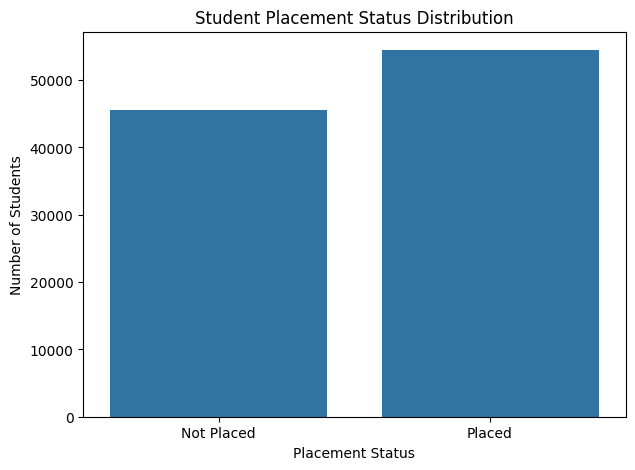

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="placement_status")

plt.title("Student Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

DATA CLEANING

In [ ]:
clean_df = df.copy()

print("Clean dataset created!")

Clean dataset created!


In [ ]:
clean_df = clean_df.drop(columns=["student_id"])

print("student_id removed.")

student_id removed.


In [ ]:
clean_df = clean_df.drop(columns=["salary_package_lpa"])

print("salary_package_lpa removed.")

salary_package_lpa removed.


In [ ]:
clean_df = clean_df.drop(columns=["salary_package_lpa"])

print("salary_package_lpa removed.")

KeyError: "['salary_package_lpa'] not found in axis"

In [ ]:
print("Rows:", clean_df.shape[0])
print("Columns:", clean_df.shape[1])

Rows: 100000
Columns: 24


In [ ]:
print(clean_df.columns.tolist())

['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status']


In [ ]:
print(clean_df.isnull().sum())

age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
dtype: int64


Duplicate Records

In [ ]:
print("Duplicate records:", clean_df.duplicated().sum())

Duplicate records: 0


Check Data Types

In [ ]:
clean_df.dtypes

,0
age,int64
gender,object
cgpa,float64
branch,object
college_tier,object
internships_count,int64
projects_count,int64
certifications_count,int64
coding_skill_score,float64
aptitude_score,float64


Check Categorical Values

In [ ]:
categorical_columns = [
    "gender",
    "branch",
    "college_tier",
    "volunteer_experience"
]

for col in categorical_columns:
    print("\n" + "="*40)
    print(col)
    print(clean_df[col].unique())


gender
['Male' 'Female']

branch
['IT' 'CSE' 'EEE' 'Civil' 'Mechanical' 'ECE']

college_tier
['Tier 2' 'Tier 1' 'Tier 3']

volunteer_experience
['Yes' 'No']


EXPLORATORY DATA ANALYSIS

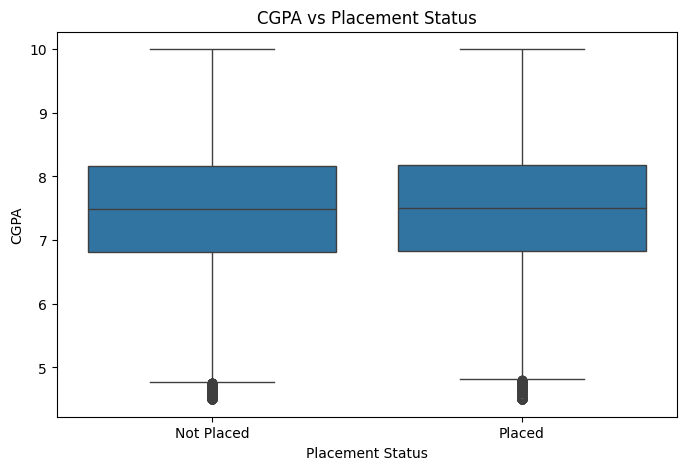

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=clean_df, x="placement_status", y="cgpa")

plt.title("CGPA vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")

plt.show()

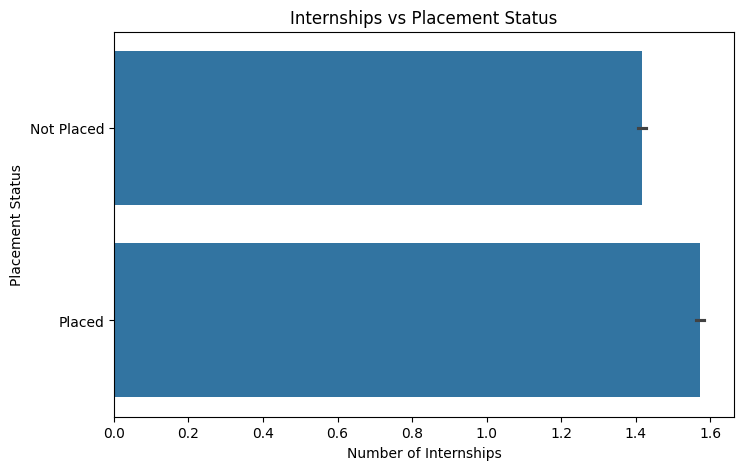

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clean_df,
    x="internships_count",
    y="placement_status"
)

plt.title("Internships vs Placement Status")
plt.xlabel("Number of Internships")
plt.ylabel("Placement Status")

plt.show()

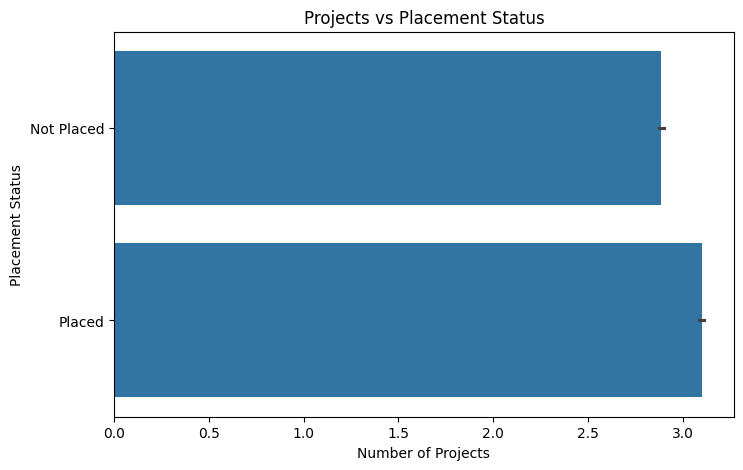

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=clean_df,
    x="projects_count",
    y="placement_status"
)

plt.title("Projects vs Placement Status")
plt.xlabel("Number of Projects")
plt.ylabel("Placement Status")

plt.show()

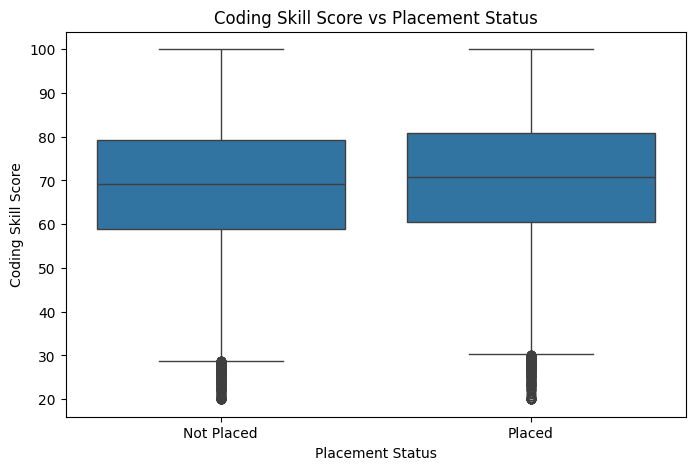

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="coding_skill_score"
)

plt.title("Coding Skill Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Coding Skill Score")

plt.show()

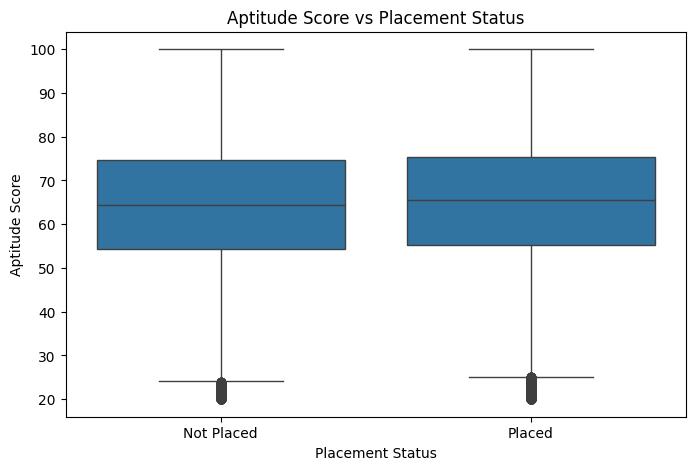

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="aptitude_score"
)

plt.title("Aptitude Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Aptitude Score")

plt.show()

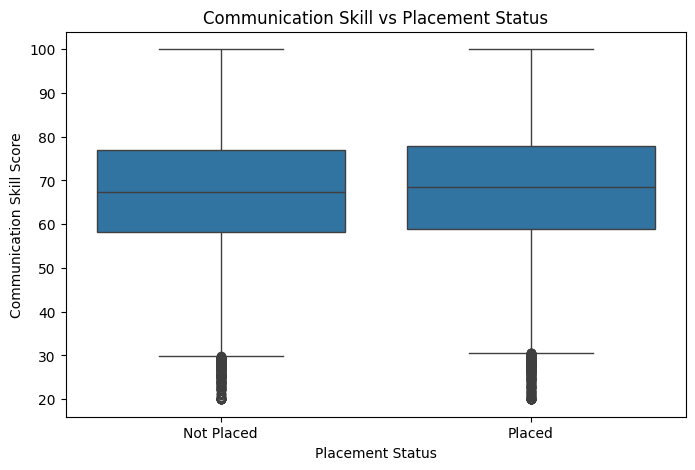

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="communication_skill_score"
)

plt.title("Communication Skill vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Communication Skill Score")

plt.show()

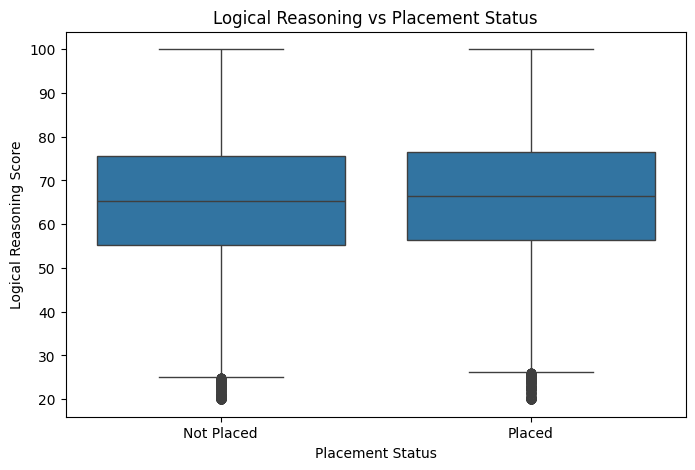

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="logical_reasoning_score"
)

plt.title("Logical Reasoning vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Logical Reasoning Score")

plt.show()

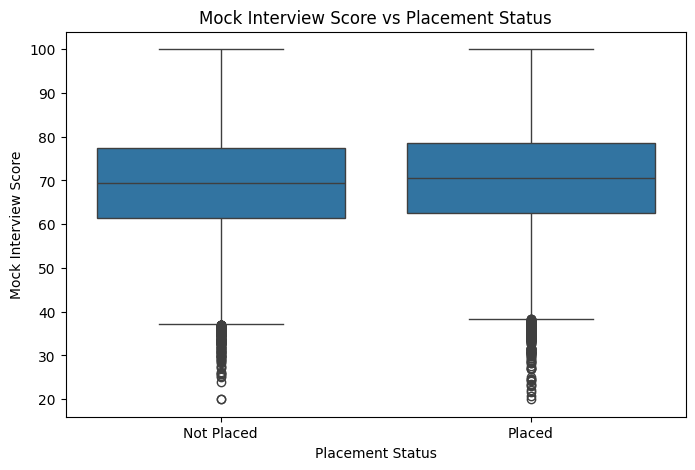

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="mock_interview_score"
)

plt.title("Mock Interview Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Mock Interview Score")

plt.show()

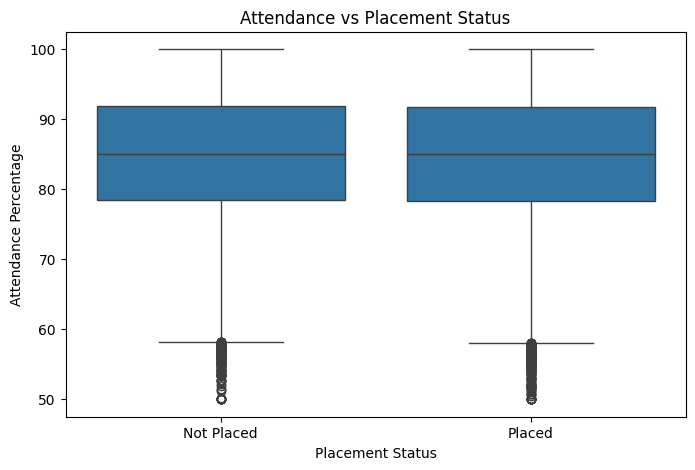

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="attendance_percentage"
)

plt.title("Attendance vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Attendance Percentage")

plt.show()

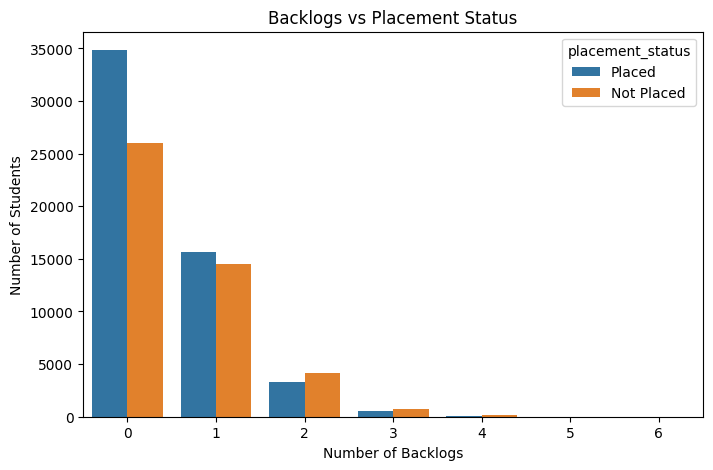

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="backlogs",
    hue="placement_status"
)

plt.title("Backlogs vs Placement Status")
plt.xlabel("Number of Backlogs")
plt.ylabel("Number of Students")

plt.show()

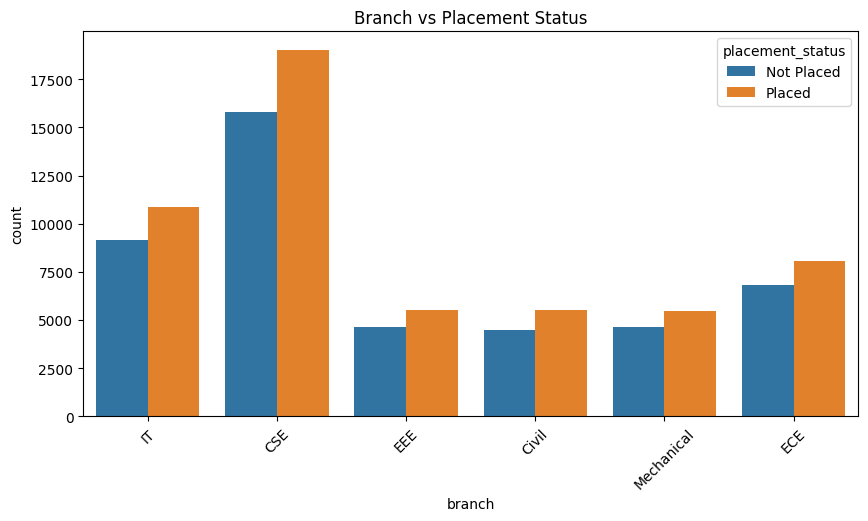

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=clean_df,
    x="branch",
    hue="placement_status"
)

plt.title("Branch vs Placement Status")
plt.xticks(rotation=45)

plt.show()

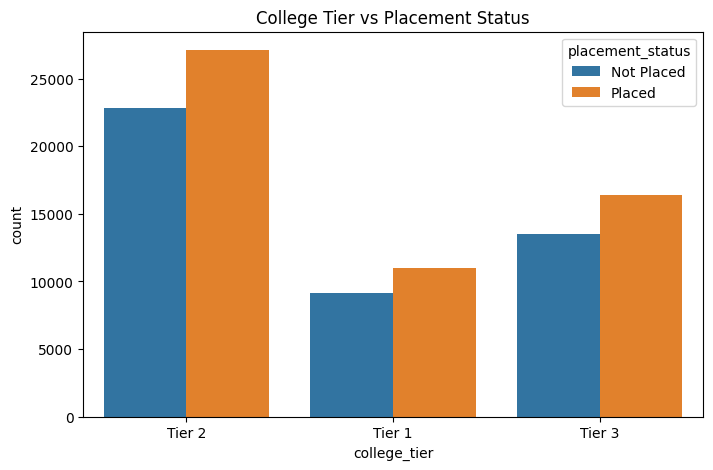

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="college_tier",
    hue="placement_status"
)

plt.title("College Tier vs Placement Status")

plt.show()

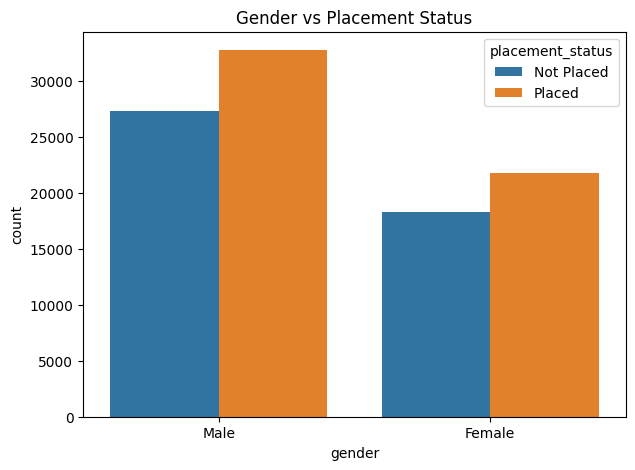

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=clean_df,
    x="gender",
    hue="placement_status"
)

plt.title("Gender vs Placement Status")

plt.show()

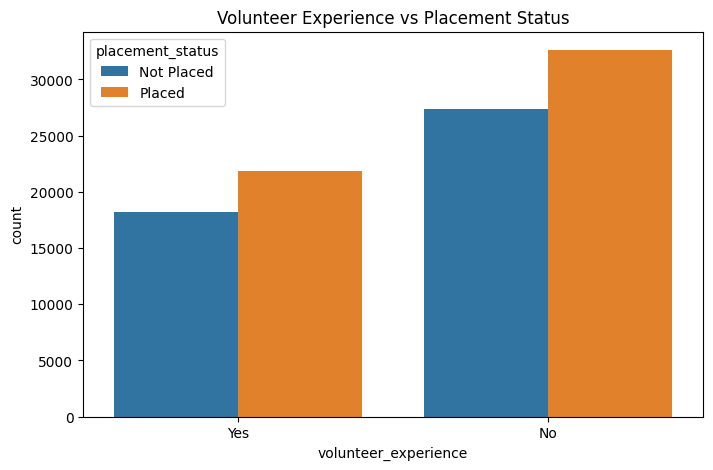

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="volunteer_experience",
    hue="placement_status"
)

plt.title("Volunteer Experience vs Placement Status")

plt.show()

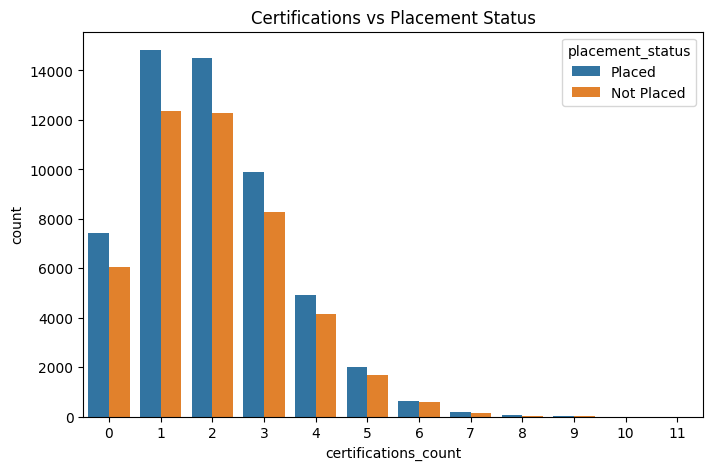

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="certifications_count",
    hue="placement_status"
)

plt.title("Certifications vs Placement Status")

plt.show()

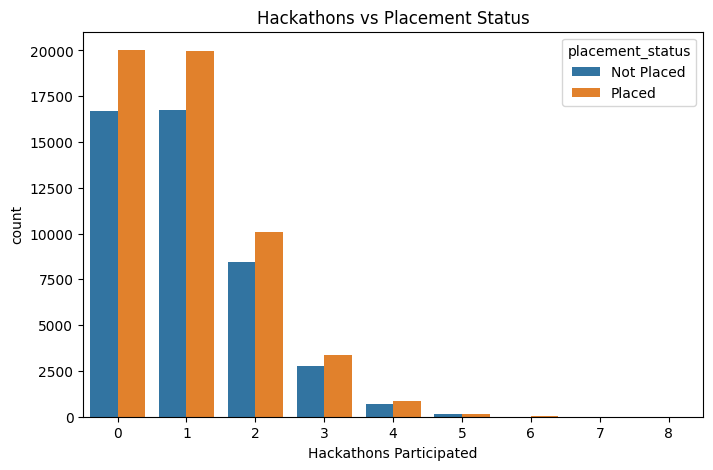

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=clean_df,
    x="hackathons_participated",
    hue="placement_status"
)

plt.title("Hackathons vs Placement Status")
plt.xlabel("Hackathons Participated")

plt.show()

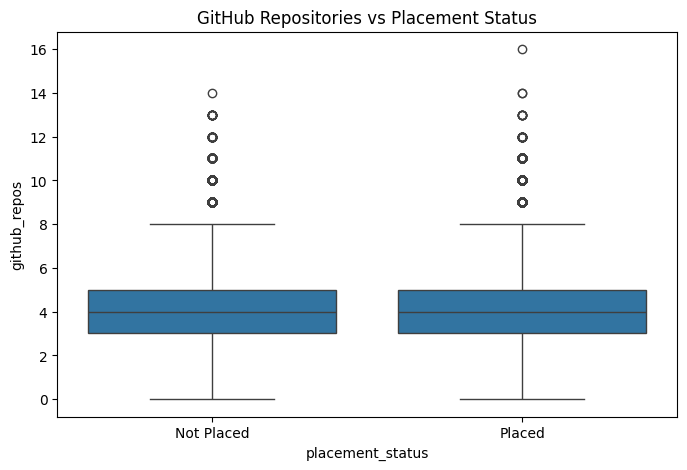

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="github_repos"
)

plt.title("GitHub Repositories vs Placement Status")

plt.show()

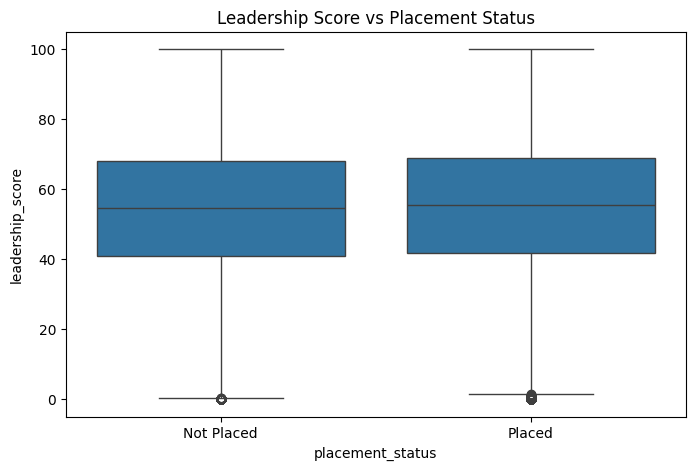

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=clean_df,
    x="placement_status",
    y="leadership_score"
)

plt.title("Leadership Score vs Placement Status")

plt.show()

In [ ]:
correlation_df = clean_df.copy()

correlation_df["placement_status_numeric"] = (
    correlation_df["placement_status"]
    .map({"Placed": 1, "Not Placed": 0})
)

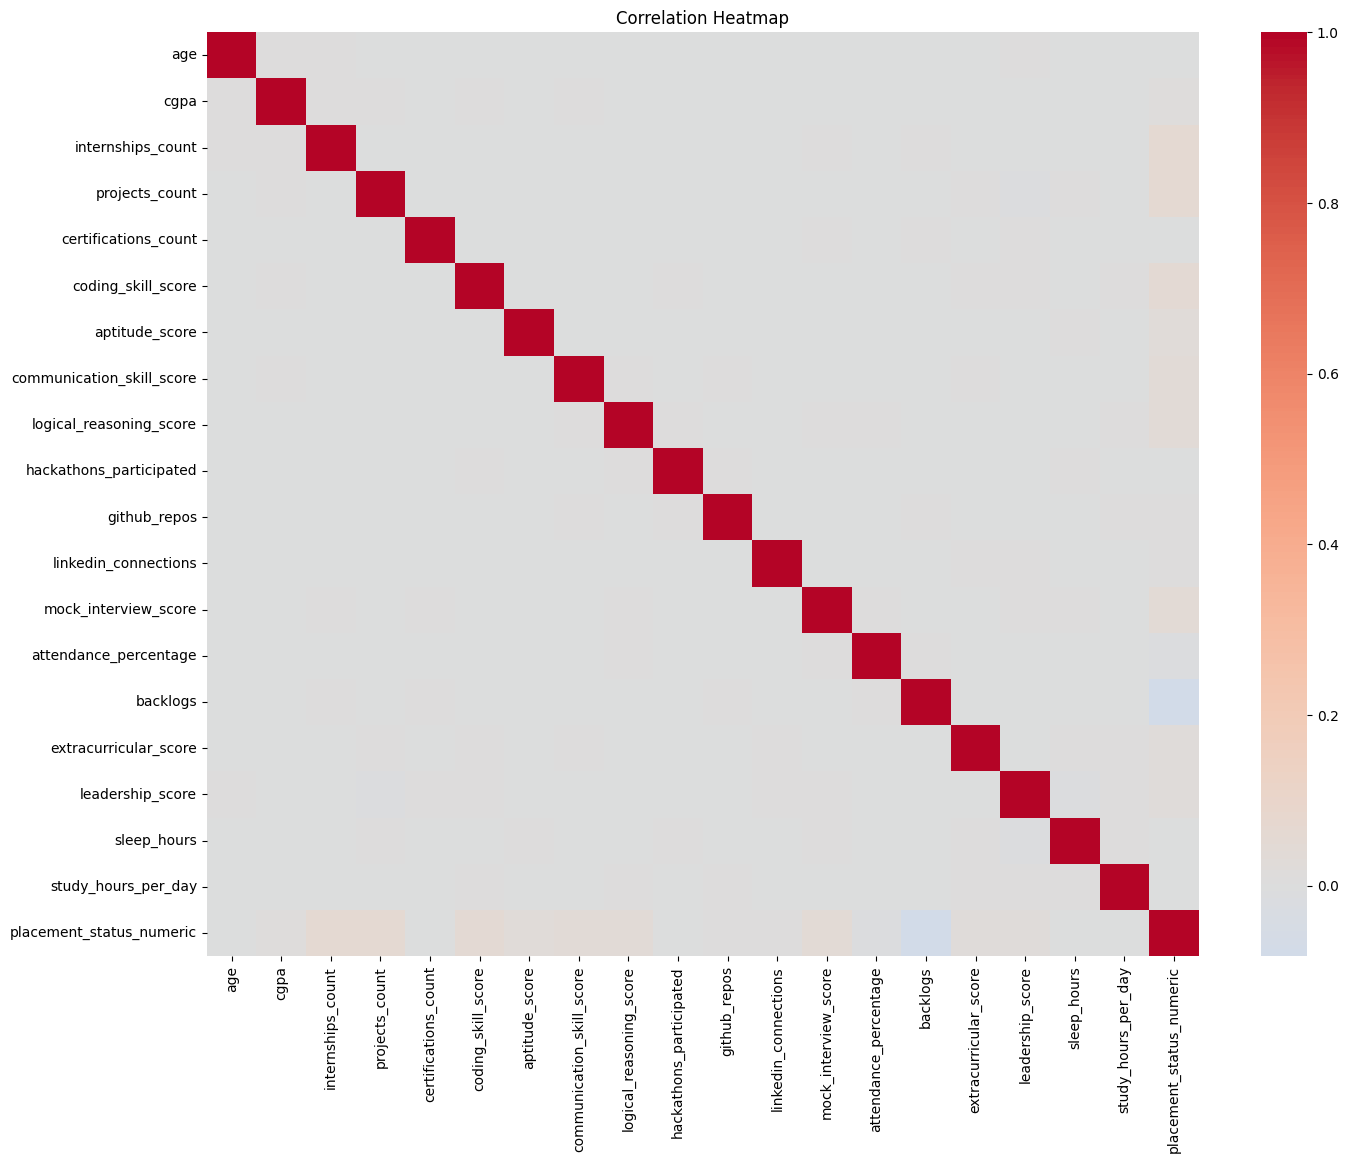

In [ ]:
correlation_matrix = correlation_df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
placement_corr = (
    correlation_matrix["placement_status_numeric"]
    .sort_values(ascending=False)
)

print(placement_corr)

placement_status_numeric     1.000000
internships_count            0.063489
projects_count               0.060964
coding_skill_score           0.050773
mock_interview_score         0.046058
logical_reasoning_score      0.036332
communication_skill_score    0.032242
aptitude_score               0.031690
leadership_score             0.022170
extracurricular_score        0.020100
cgpa                         0.012067
github_repos                 0.004807
linkedin_connections         0.003223
hackathons_participated      0.001236
age                          0.000858
study_hours_per_day         -0.001426
certifications_count        -0.003806
sleep_hours                 -0.004692
attendance_percentage       -0.008350
backlogs                    -0.082404
Name: placement_status_numeric, dtype: float64


FEATURE & TARGET SEPARATION

In [ ]:
clean_df["placement_status"] = clean_df["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})

In [ ]:
clean_df["placement_status"].value_counts()

,count
placement_status,


Separate X and y

In [ ]:
X = clean_df.drop(columns=["placement_status"])
y = clean_df["placement_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 23)
y shape: (100000,)


TRAIN/TEST SPLIT

In [ ]:
print(clean_df["placement_status"].unique())

[nan]


In [ ]:
print(clean_df["placement_status"].value_counts(dropna=False))

placement_status
NaN    100000
Name: count, dtype: int64


In [ ]:
# Recreate clean dataset from the original dataset
clean_df = df.copy()

# Remove columns that should not be used
clean_df = clean_df.drop(
    columns=["student_id", "salary_package_lpa"]
)

# Clean the placement status text
clean_df["placement_status"] = (
    clean_df["placement_status"]
    .astype(str)
    .str.strip()
)

# Convert placement status to 0 and 1
clean_df["placement_status"] = clean_df["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})

print("Data preprocessing completed!")

Data preprocessing completed!


In [ ]:
print(clean_df["placement_status"].unique())
print(clean_df["placement_status"].value_counts(dropna=False))

[0 1]
placement_status
1    54459
0    45541
Name: count, dtype: int64


In [ ]:
print("Missing values in placement_status:",
      clean_df["placement_status"].isna().sum())

Missing values in placement_status: 0


In [ ]:
X = clean_df.drop(columns=["placement_status"])
y = clean_df["placement_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 23)
y shape: (100000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 80000
Testing samples: 20000


Identify Categorical & Numerical Columns

In [ ]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'branch', 'college_tier', 'volunteer_experience']

Numerical Features:
['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']


Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


Training the 4 required ML models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

print("All four ML models imported successfully!")

All four ML models imported successfully!


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

print("All four models created successfully!")

All four models created successfully!


Train the Models

In [ ]:
trained_models = {}

for name, model in models.items():

    print("Training:", name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

print("\nAll four models trained successfully!")

Training: Logistic Regression
Training: Random Forest
Training: SVM
Training: KNN

All four models trained successfully!


In [ ]:
print(trained_models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'SVM', 'KNN'])


Make Predictions

In [ ]:
predictions = {}

for name, model in trained_models.items():

    predictions[name] = model.predict(X_test)

    print(name, "prediction completed.")

Logistic Regression prediction completed.
Random Forest prediction completed.
SVM prediction completed.
KNN prediction completed.


Evaluation Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, y_pred in predictions.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.57005,0.578889,0.772402,0.661790
1,Random Forest,0.55265,0.570825,0.719611,0.636641
2,SVM,0.56105,0.569365,0.796181,0.663936
3,KNN,0.52115,0.556221,0.597227,0.575995


Model Comparison Graph

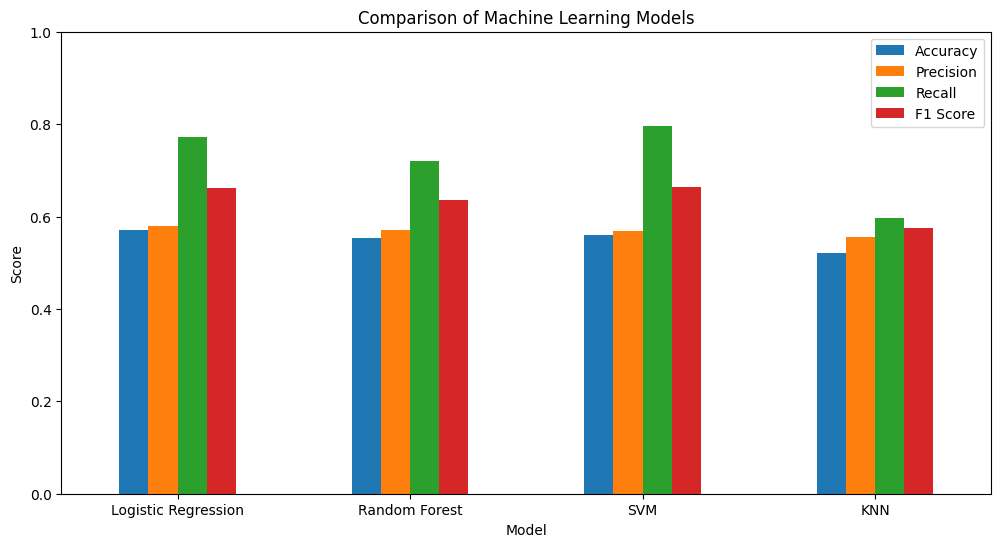

In [ ]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

Exact Model Results

In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.57005,0.578889,0.772402,0.661790
1,Random Forest,0.55265,0.570825,0.719611,0.636641
2,SVM,0.56105,0.569365,0.796181,0.663936
3,KNN,0.52115,0.556221,0.597227,0.575995


Automatically Select the Best Model

In [ ]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Selected model based on highest F1 Score:")
print(best_model_name)

Selected model based on highest F1 Score:
SVM


Get Predictions From Selected Model

In [ ]:
best_model = trained_models[best_model_name]

y_best_pred = best_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_best_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2549 6559]
 [2220 8672]]


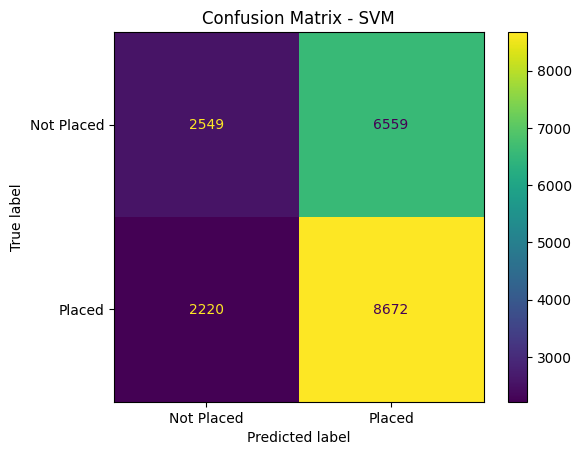

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_best_pred,
        target_names=["Not Placed", "Placed"]
    )
)

              precision    recall  f1-score   support

  Not Placed       0.53      0.28      0.37      9108
      Placed       0.57      0.80      0.66     10892

    accuracy                           0.56     20000
   macro avg       0.55      0.54      0.52     20000
weighted avg       0.55      0.56      0.53     20000



Check Exact TP, TN, FP, FN

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive  :", tp)

True Negative : 2549
False Positive: 6559
False Negative: 2220
True Positive  : 8672


RANDOM FOREST FEATURE IMPORTANCE

In [ ]:
rf_pipeline = trained_models["Random Forest"]

rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [ ]:
feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
12,num__mock_interview_score,0.064594
5,num__coding_skill_score,0.064546
6,num__aptitude_score,0.063850
8,num__logical_reasoning_score,0.063572
7,num__communication_skill_score,0.063340
16,num__leadership_score,0.062799
15,num__extracurricular_score,0.062338
11,num__linkedin_connections,0.061565
1,num__cgpa,0.060746
13,num__attendance_percentage,0.060080


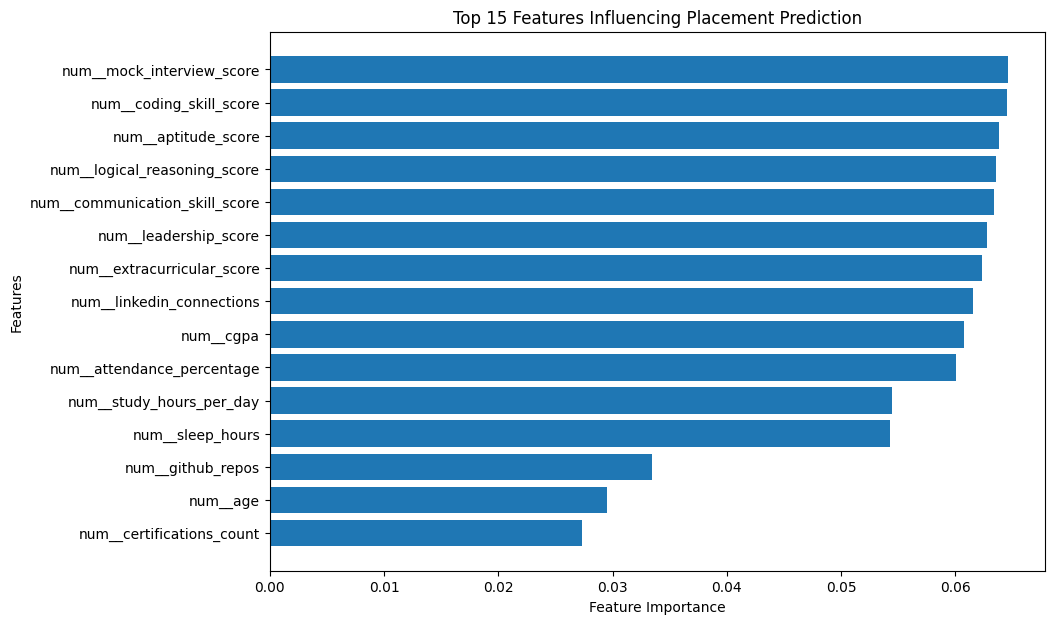

In [ ]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Placement Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

In [ ]:
print("Top 10 Important Features:")
print("--------------------------------")

for i, row in feature_importance_df.head(10).reset_index(drop=True).iterrows():
    print(
        f"{i+1}. {row['Feature']} : "
        f"{row['Importance']:.4f}"
    )

Top 10 Important Features:
--------------------------------
1. num__mock_interview_score : 0.0646
2. num__coding_skill_score : 0.0645
3. num__aptitude_score : 0.0638
4. num__logical_reasoning_score : 0.0636
5. num__communication_skill_score : 0.0633
6. num__leadership_score : 0.0628
7. num__extracurricular_score : 0.0623
8. num__linkedin_connections : 0.0616
9. num__cgpa : 0.0607
10. num__attendance_percentage : 0.0601


MODEL IMPROVEMENT

In [ ]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully!")

GridSearchCV imported successfully!


In [ ]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

print("SVM parameter grid created!")

SVM parameter grid created!


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create SVM pipeline
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

# Hyperparameters to test
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

print("SVM pipeline and parameter grid created successfully!")

NameError: name 'preprocessor' is not defined

In [4]:
import pandas as pd
import numpy as np

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Saving student_placement_prediction_dataset_2026.csv to student_placement_prediction_dataset_2026.csv
Dataset loaded successfully!
Shape: (100000, 26)


In [5]:
# Create a fresh copy
clean_df = df.copy()

# Remove ID and salary package
clean_df = clean_df.drop(
    columns=["student_id", "salary_package_lpa"],
    errors="ignore"
)

# Clean placement status
clean_df["placement_status"] = (
    clean_df["placement_status"]
    .astype(str)
    .str.strip()
)

# Convert target into 0 and 1
clean_df["placement_status"] = clean_df["placement_status"].map({
    "Not Placed": 0,
    "Placed": 1
})

# Remove rows where target could not be converted
clean_df = clean_df.dropna(subset=["placement_status"])

print("Clean dataset created!")
print("Shape:", clean_df.shape)
print("\nTarget distribution:")
print(clean_df["placement_status"].value_counts())

Clean dataset created!
Shape: (100000, 24)

Target distribution:
placement_status
1    54459
0    45541
Name: count, dtype: int64


In [6]:
X = clean_df.drop(columns=["placement_status"])
y = clean_df["placement_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 23)
y shape: (100000,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 80000
Testing samples: 20000


In [8]:
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 19
Number of categorical features: 4

Numerical features:
['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']

Categorical features:
['gender', 'branch', 'college_tier', 'volunteer_experience']


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [10]:
print("X:", X.shape)
print("y:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Preprocessor:", type(preprocessor).__name__)

X: (100000, 23)
y: (100000,)
X_train: (80000, 23)
X_test: (20000, 23)
y_train: (80000,)
y_test: (20000,)
Preprocessor: ColumnTransformer


In [11]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

print("SVM pipeline created successfully!")

SVM pipeline created successfully!


In [12]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=False,
        C=1,
        kernel="rbf",
        random_state=42
    ))
])

print("Light SVM pipeline created successfully!")

Light SVM pipeline created successfully!


In [13]:
print("Training Light SVM...")

svm_pipeline.fit(X_train, y_train)

print("Light SVM training completed!")

Training Light SVM...
Light SVM training completed!


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions
y_svm_pred = svm_pipeline.predict(X_test)

# Calculate metrics
svm_accuracy = accuracy_score(y_test, y_svm_pred)
svm_precision = precision_score(y_test, y_svm_pred)
svm_recall = recall_score(y_test, y_svm_pred)
svm_f1 = f1_score(y_test, y_svm_pred)

print("SVM Results")
print("----------------------")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))

SVM Results
----------------------
Accuracy : 0.5611
Precision: 0.5694
Recall   : 0.7962
F1 Score : 0.6639


In [15]:
from sklearn.metrics import classification_report

print("SVM Classification Report")
print("=========================")

print(classification_report(
    y_test,
    y_svm_pred,
    target_names=["Not Placed", "Placed"]
))

SVM Classification Report
              precision    recall  f1-score   support

  Not Placed       0.53      0.28      0.37      9108
      Placed       0.57      0.80      0.66     10892

    accuracy                           0.56     20000
   macro avg       0.55      0.54      0.52     20000
weighted avg       0.55      0.56      0.53     20000



Confusion Matrix

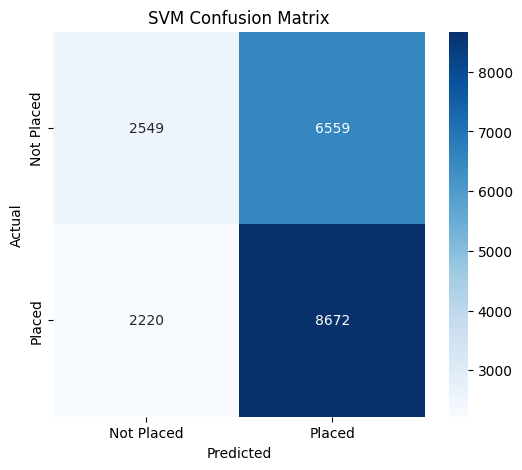

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_svm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [17]:
svm_results = {
    "Model": "SVM",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1
}

print(svm_results)

{'Model': 'SVM', 'Accuracy': 0.56105, 'Precision': 0.5693651106296369, 'Recall': 0.7961806830701432, 'F1 Score': 0.6639359951001034}


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [19]:
print("Training Logistic Regression...")

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_logistic_pred = logistic_pipeline.predict(X_test)

logistic_accuracy = accuracy_score(y_test, y_logistic_pred)
logistic_precision = precision_score(y_test, y_logistic_pred)
logistic_recall = recall_score(y_test, y_logistic_pred)
logistic_f1 = f1_score(y_test, y_logistic_pred)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.57
Precision: 0.5789
Recall   : 0.7724
F1 Score : 0.6618


Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [22]:
print("Training Random Forest...")

rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_rf_pred = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_rf_pred)
rf_precision = precision_score(y_test, y_rf_pred)
rf_recall = recall_score(y_test, y_rf_pred)
rf_f1 = f1_score(y_test, y_rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Results
---------------------
Accuracy : 0.5526
Precision: 0.5708
Recall   : 0.7196
F1 Score : 0.6366


KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ))
])

print("KNN pipeline created successfully!")

KNN pipeline created successfully!


In [25]:
print("Training KNN...")

knn_pipeline.fit(X_train, y_train)

print("KNN training completed!")

Training KNN...
KNN training completed!


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_knn_pred = knn_pipeline.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_knn_pred)
knn_precision = precision_score(y_test, y_knn_pred)
knn_recall = recall_score(y_test, y_knn_pred)
knn_f1 = f1_score(y_test, y_knn_pred)

print("KNN Results")
print("----------------")
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1 Score :", round(knn_f1, 4))

KNN Results
----------------
Accuracy : 0.5212
Precision: 0.5562
Recall   : 0.5972
F1 Score : 0.576


final comparison table + graph

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,57.00,57.89,77.24,66.18
1,Random Forest,55.26,57.08,71.96,63.66
2,SVM,56.10,56.94,79.62,66.39
3,KNN,52.12,55.62,59.72,57.60


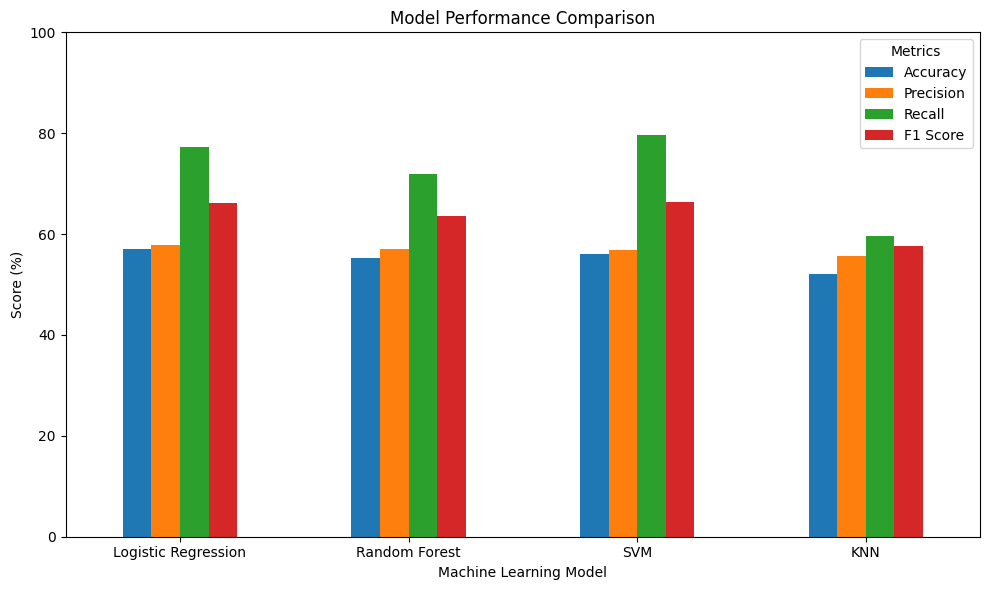

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Create final comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        svm_accuracy,
        knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        svm_precision,
        knn_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        svm_recall,
        knn_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1,
        svm_f1,
        knn_f1
    ]
})

# Display percentages
comparison_display = model_comparison.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    comparison_display[column] = (
        comparison_display[column] * 100
    ).round(2)

print("FINAL MODEL COMPARISON")
print("======================")
display(comparison_display)

# Create comparison graph
comparison_display.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

Confusion Matrix for Logistic Regression

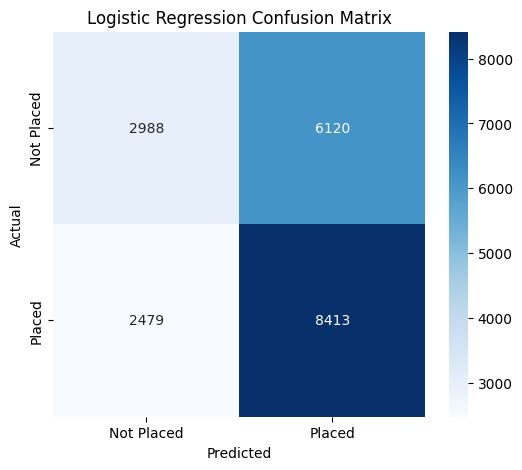

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_logistic = confusion_matrix(y_test, y_logistic_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Random Forest Confusion Matrix

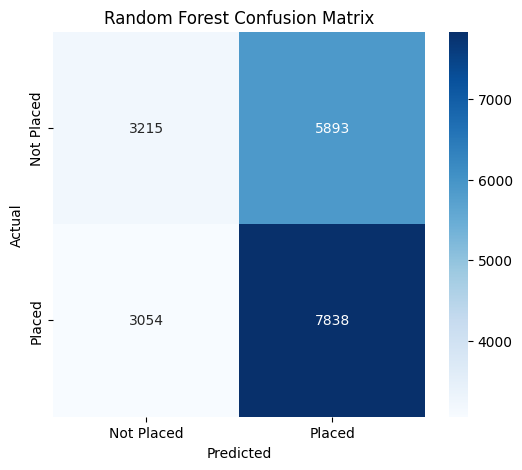

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

KNN Confusion Matrix

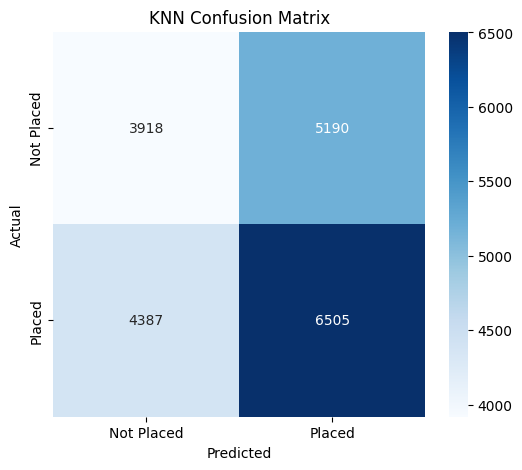

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_knn = confusion_matrix(y_test, y_knn_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

Random Forest Feature Importance

In [31]:
# Get the trained Random Forest model
rf_model = rf_pipeline.named_steps["model"]

# Get the preprocessing step
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

# Get transformed feature names
feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importance values
importance_values = rf_model.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print("Top 15 Important Features")
print("=========================")
display(feature_importance_df.head(15))

Top 15 Important Features


,Feature,Importance
12,num__mock_interview_score,0.064594
5,num__coding_skill_score,0.064546
6,num__aptitude_score,0.063850
8,num__logical_reasoning_score,0.063572
7,num__communication_skill_score,0.063340
16,num__leadership_score,0.062799
15,num__extracurricular_score,0.062338
11,num__linkedin_connections,0.061565
1,num__cgpa,0.060746
13,num__attendance_percentage,0.060080


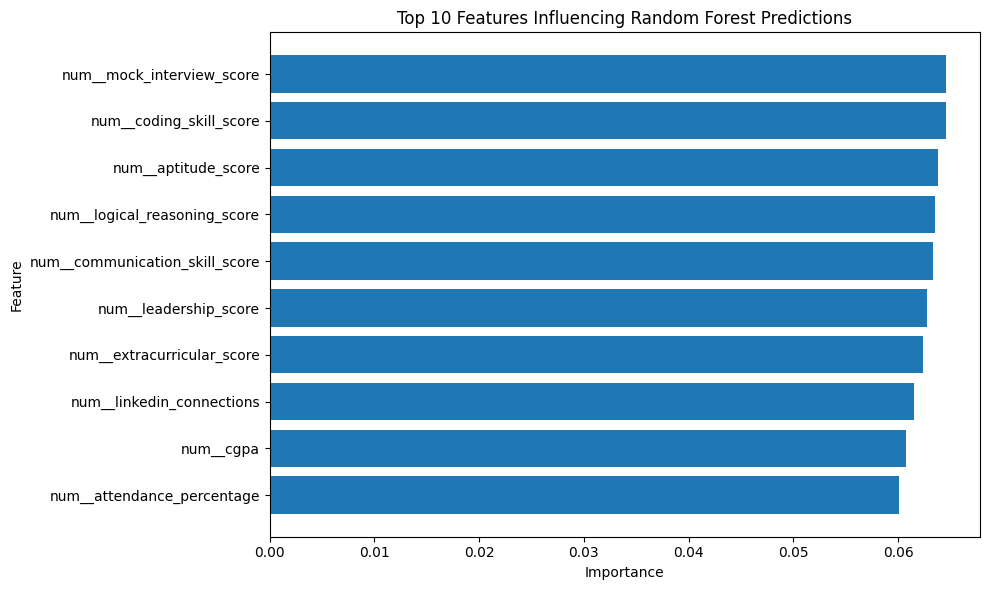

In [32]:
top_features = feature_importance_df.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Random Forest Predictions")
plt.tight_layout()
plt.show()

the actual prediction system

In [33]:
# Take one student from the test dataset
sample_student = X_test.iloc[[0]]

# Predict placement status
prediction = rf_pipeline.predict(sample_student)[0]

print("Student Placement Prediction")
print("============================")

if prediction == 1:
    print("Prediction: PLACED")
else:
    print("Prediction: NOT PLACED")

Student Placement Prediction
Prediction: PLACED


all input features

In [34]:
print("INPUT FEATURES")
print("================")

for i, column in enumerate(X.columns, 1):
    print(i, "-", column, "|", X[column].dtype)

INPUT FEATURES
1 - age | int64
2 - gender | object
3 - cgpa | float64
4 - branch | object
5 - college_tier | object
6 - internships_count | int64
7 - projects_count | int64
8 - certifications_count | int64
9 - coding_skill_score | float64
10 - aptitude_score | float64
11 - communication_skill_score | float64
12 - logical_reasoning_score | float64
13 - hackathons_participated | int64
14 - github_repos | int64
15 - linkedin_connections | int64
16 - mock_interview_score | float64
17 - attendance_percentage | float64
18 - backlogs | int64
19 - extracurricular_score | float64
20 - leadership_score | float64
21 - volunteer_experience | object
22 - sleep_hours | float64
23 - study_hours_per_day | float64


categorical values

In [35]:
categorical_columns = [
    "gender",
    "branch",
    "college_tier",
    "volunteer_experience"
]

print("CATEGORICAL VALUES")
print("==================")

for column in categorical_columns:
    print(f"\n{column}:")
    print(X[column].dropna().unique())

CATEGORICAL VALUES

gender:
['Male' 'Female']

branch:
['IT' 'CSE' 'EEE' 'Civil' 'Mechanical' 'ECE']

college_tier:
['Tier 2' 'Tier 1' 'Tier 3']

volunteer_experience:
['Yes' 'No']


the actual prediction interface

In [36]:
# Install Gradio
!pip -q install gradio

import gradio as gr
import pandas as pd

# Prediction function
def predict_placement(
    age,
    gender,
    cgpa,
    branch,
    college_tier,
    internships_count,
    projects_count,
    certifications_count,
    coding_skill_score,
    aptitude_score,
    communication_skill_score,
    logical_reasoning_score,
    hackathons_participated,
    github_repos,
    linkedin_connections,
    mock_interview_score,
    attendance_percentage,
    backlogs,
    extracurricular_score,
    leadership_score,
    volunteer_experience,
    sleep_hours,
    study_hours_per_day
):

    # Create student data in the exact feature order
    student_data = pd.DataFrame([{
        "age": age,
        "gender": gender,
        "cgpa": cgpa,
        "branch": branch,
        "college_tier": college_tier,
        "internships_count": internships_count,
        "projects_count": projects_count,
        "certifications_count": certifications_count,
        "coding_skill_score": coding_skill_score,
        "aptitude_score": aptitude_score,
        "communication_skill_score": communication_skill_score,
        "logical_reasoning_score": logical_reasoning_score,
        "hackathons_participated": hackathons_participated,
        "github_repos": github_repos,
        "linkedin_connections": linkedin_connections,
        "mock_interview_score": mock_interview_score,
        "attendance_percentage": attendance_percentage,
        "backlogs": backlogs,
        "extracurricular_score": extracurricular_score,
        "leadership_score": leadership_score,
        "volunteer_experience": volunteer_experience,
        "sleep_hours": sleep_hours,
        "study_hours_per_day": study_hours_per_day
    }])

    # Prediction
    prediction = rf_pipeline.predict(student_data)[0]

    # Probability
    probability = rf_pipeline.predict_proba(student_data)[0]

    if prediction == 1:
        result = "🎉 PLACED"
        confidence = probability[1] * 100
    else:
        result = "❌ NOT PLACED"
        confidence = probability[0] * 100

    return f"{result}\n\nPrediction Confidence: {confidence:.2f}%"


# Create interface
with gr.Blocks(title="Student Placement Prediction System") as demo:

    gr.Markdown(
        """
        # 🎓 Student Placement Prediction System

        Enter the student's academic, technical and extracurricular details
        to predict their placement status.
        """
    )

    with gr.Row():
        with gr.Column():
            age = gr.Number(label="Age", value=21)
            gender = gr.Dropdown(
                ["Male", "Female"],
                label="Gender",
                value="Male"
            )
            cgpa = gr.Number(label="CGPA", value=8.0)
            branch = gr.Dropdown(
                ["IT", "CSE", "EEE", "Civil", "Mechanical", "ECE"],
                label="Branch",
                value="CSE"
            )
            college_tier = gr.Dropdown(
                ["Tier 1", "Tier 2", "Tier 3"],
                label="College Tier",
                value="Tier 2"
            )
            internships_count = gr.Number(
                label="Internships Count", value=1
            )
            projects_count = gr.Number(
                label="Projects Count", value=2
            )
            certifications_count = gr.Number(
                label="Certifications Count", value=2
            )

        with gr.Column():
            coding_skill_score = gr.Number(
                label="Coding Skill Score", value=70
            )
            aptitude_score = gr.Number(
                label="Aptitude Score", value=70
            )
            communication_skill_score = gr.Number(
                label="Communication Skill Score", value=70
            )
            logical_reasoning_score = gr.Number(
                label="Logical Reasoning Score", value=70
            )
            hackathons_participated = gr.Number(
                label="Hackathons Participated", value=1
            )
            github_repos = gr.Number(
                label="GitHub Repositories", value=5
            )
            linkedin_connections = gr.Number(
                label="LinkedIn Connections", value=300
            )
            mock_interview_score = gr.Number(
                label="Mock Interview Score", value=70
            )

        with gr.Column():
            attendance_percentage = gr.Number(
                label="Attendance Percentage", value=85
            )
            backlogs = gr.Number(
                label="Backlogs", value=0
            )
            extracurricular_score = gr.Number(
                label="Extracurricular Score", value=70
            )
            leadership_score = gr.Number(
                label="Leadership Score", value=70
            )
            volunteer_experience = gr.Dropdown(
                ["Yes", "No"],
                label="Volunteer Experience",
                value="Yes"
            )
            sleep_hours = gr.Number(
                label="Sleep Hours", value=7
            )
            study_hours_per_day = gr.Number(
                label="Study Hours Per Day", value=5
            )

    predict_button = gr.Button(
        "🔮 Predict Placement",
        variant="primary"
    )

    output = gr.Textbox(
        label="Prediction Result",
        lines=3
    )

    predict_button.click(
        fn=predict_placement,
        inputs=[
            age,
            gender,
            cgpa,
            branch,
            college_tier,
            internships_count,
            projects_count,
            certifications_count,
            coding_skill_score,
            aptitude_score,
            communication_skill_score,
            logical_reasoning_score,
            hackathons_participated,
            github_repos,
            linkedin_connections,
            mock_interview_score,
            attendance_percentage,
            backlogs,
            extracurricular_score,
            leadership_score,
            volunteer_experience,
            sleep_hours,
            study_hours_per_day
        ],
        outputs=output
    )

# Launch
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://548ef52403f076e58c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [37]:
import joblib

# Save the trained model pipeline
joblib.dump(rf_pipeline, "student_placement_model.pkl")

print("Model saved successfully!")
print("File: student_placement_model.pkl")

Model saved successfully!
File: student_placement_model.pkl


In [38]:
import joblib

joblib.dump(rf_pipeline, "student_placement_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [39]:
# Example student prediction

sample_student = X_test.iloc[[0]]

prediction = rf_pipeline.predict(sample_student)[0]
probability = rf_pipeline.predict_proba(sample_student)[0]

print("FINAL PREDICTION")
print("================")

if prediction == 1:
    print("Placement Status: PLACED")
    print(f"Confidence: {probability[1] * 100:.2f}%")
else:
    print("Placement Status: NOT PLACED")
    print(f"Confidence: {probability[0] * 100:.2f}%")

FINAL PREDICTION
Placement Status: PLACED
Confidence: 54.00%


Conclusion

The Student Placement Prediction System uses machine learning to predict whether a student is likely to be placed based on academic, technical, and extracurricular attributes. Four classification models—Logistic Regression, Random Forest, SVM, and KNN—were implemented and evaluated using Accuracy, Precision, Recall, and F1 Score.

The project also includes feature-importance analysis and an interactive Gradio-based prediction interface. The system demonstrates how machine learning can be applied to student placement data as a predictive decision-support tool.

The predictions should be interpreted as model outputs based on the dataset and should not be treated as a guarantee of an individual's actual placement outcome.